<a href="https://colab.research.google.com/github/kaoru1018/Thai_tourism_analysis-2019-2023/blob/main/Thai_tourism_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✓ 読み込み成功: 30,800 行 × 7 項目（タイの観光データ）
📖 読み込んだファイル: thailand_domestic_tourism_2019_2023_ver2.csv
--- データの先頭5行 ---


,date,province_thai,province_eng,region_thai,region_eng,variable,value
0,2019-01-01,กรุงเทพมหานคร,Bangkok,ภาคกลาง,central,ratio_tourist_stay,93.37
1,2019-01-01,ลพบุรี,Lopburi,ภาคกลาง,central,ratio_tourist_stay,61.32
2,2019-01-01,พระนครศรีอยุธยา,Phra Nakhon Si Ayutthaya,ภาคกลาง,central,ratio_tourist_stay,73.37
3,2019-01-01,สระบุรี,Saraburi,ภาคกลาง,central,ratio_tourist_stay,67.33
4,2019-01-01,ชัยนาท,Chainat,ภาคกลาง,central,ratio_tourist_stay,79.31


--- データに含まれる項目の一覧 ---
['ratio_tourist_stay' 'no_tourist_stay' 'no_tourist_all' 'no_tourist_thai'
 'no_tourist_foreign' 'revenue_all' 'revenue_thai' 'revenue_foreign']
👑 【タイ人国内旅行】 に大人気の県 TOP10
province_eng
Bangkok                      106899866.0
Kanchanaburi                  33180427.0
Chonburi                      32260927.0
Phetchaburi                   27306554.0
Nakhon Ratchasima             26118369.0
Chiang Mai                    25858062.0
Prachuap Khiri Khan           24206578.0
Phra Nakhon Si Ayutthaya      20861804.0
Rayong                        15035941.0
Khon Kaen                     13901696.0
Name: value, dtype: float64

---------------------------------------------

👑 【外国人観光客】 に大人気の県 TOP10
province_eng
Bangkok                      44452634.0
Phuket                       17525594.0
Chonburi                     14660424.0
Chiang Mai                    5904641.0
Krabi                         5457707.0
Surat Thani                   5424521.0
Songkhla                      48

/tmp/ipykernel_2875/111786175.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_2875/111786175.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


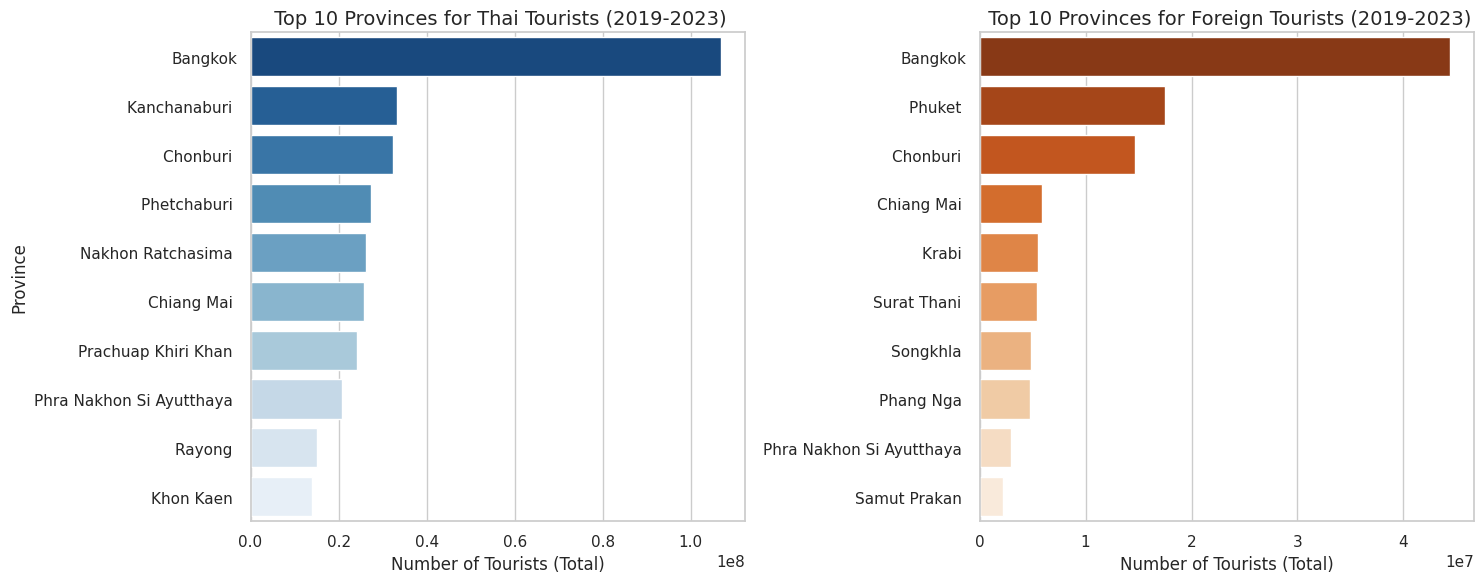

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os


# まずKaggleのフォルダの中を探します
csv_files = glob.glob("/kaggle/input/**/*.csv", recursive=True)

#  どこで動いているかに応じて、読み込むファイルの住所を自動で切り替えます
if csv_files:
    # 【Kaggleの場合】見つかったファイルを自動指定
    target_path = csv_files[0]
else:
    # 【Colabの場合】あなたがアップロードした直下のファイルを指定
    target_path = "thailand_domestic_tourism_2019_2023_ver2.csv"

#  実際にデータを読み込みます
try:
    if os.path.exists(target_path):
        df = pd.read_csv(target_path)
        print(f"✓ 読み込み成功: {df.shape[0]:,} 行 × {df.shape[1]} 項目（タイの観光データ）")
        print(f"📖 読み込んだファイル: {os.path.basename(target_path)}")
    else:
        print(
           f"❌ CSVファイルが見つかりません。ファイル名が '{target_path}' になっているか、アップロード先を確認してください。"
        )
        df = pd.DataFrame()
except Exception as e:
    print(f"❌ エラーが発生しました: {e}")
    df = pd.DataFrame()

    #  最初の5行を表示して、データの雰囲気を掴む
print("--- データの先頭5行 ---")
display(df.head())

# variableの列に、どんな種類の言葉（項目）が入っているかをすべて表示します
print("--- データに含まれる項目の一覧 ---")
print(df["variable"].unique())

# 1. タイ人観光客数（no_tourist_thai）だけを絞り込んで、県ごとに合計して、多い順に並べる
thai_ranking = (
    df[df["variable"] == "no_tourist_thai"]
    .groupby("province_eng")["value"]
    .sum()
    .sort_values(ascending=False)
)

# 2. 外国人観光客数（no_tourist_foreign）だけを絞り込んで、県ごとに合計して、多い順に並べる
foreign_ranking = (
    df[df["variable"] == "no_tourist_foreign"]
    .groupby("province_eng")["value"]
    .sum()
    .sort_values(ascending=False)
)

# 3. 両方のトップ10を並べて表示する
print("👑 【タイ人国内旅行】 に大人気の県 TOP10")
print(thai_ranking.head(10))
print("\n---------------------------------------------\n")
print("👑 【外国人観光客】 に大人気の県 TOP10")
print(foreign_ranking.head(10))

# グラフの全体のサイズを設定します（横幅15インチ、高さ6インチ）
plt.figure(figsize=(15, 6))

# --- 左側のグラフ：タイ人国内旅行 TOP10 ---
plt.subplot(1, 2, 1)  # 1行2列の画面を作って、その1番目（左）に描くという意味です
sns.barplot(
    x=thai_ranking.head(10).values,
    y=thai_ranking.head(10).index,
    palette="Blues_r",  # 青系のグラデーション（上ほど濃い）
)
plt.title(" Top 10 Provinces for Thai Tourists (2019-2023)", fontsize=14)
plt.xlabel("Number of Tourists (Total)", fontsize=12)
plt.ylabel("Province", fontsize=12)

# --- 右側のグラフ：外国人観光客 TOP10 ---
plt.subplot(1, 2, 2)  # 1行2列の2番目（右）に描くという意味です
sns.barplot(
    x=foreign_ranking.head(10).values,
    y=foreign_ranking.head(10).index,
    palette="Oranges_r",  # オレンジ系のグラデーション（上ほど濃い）
)
plt.title(" Top 10 Provinces for Foreign Tourists (2019-2023)", fontsize=14)
plt.xlabel("Number of Tourists (Total)", fontsize=12)
plt.ylabel("")  # 右側は県名が重複するので、見た目をスッキリさせるために省略します

# 左右のグラフが被らないように、自動で綺麗な隙間に調整します
plt.tight_layout()

# 画面にグラフをドンと表示します！
plt.show()



✓ 読み込み成功: 30,800 行 × 7 項目（タイの観光データ）


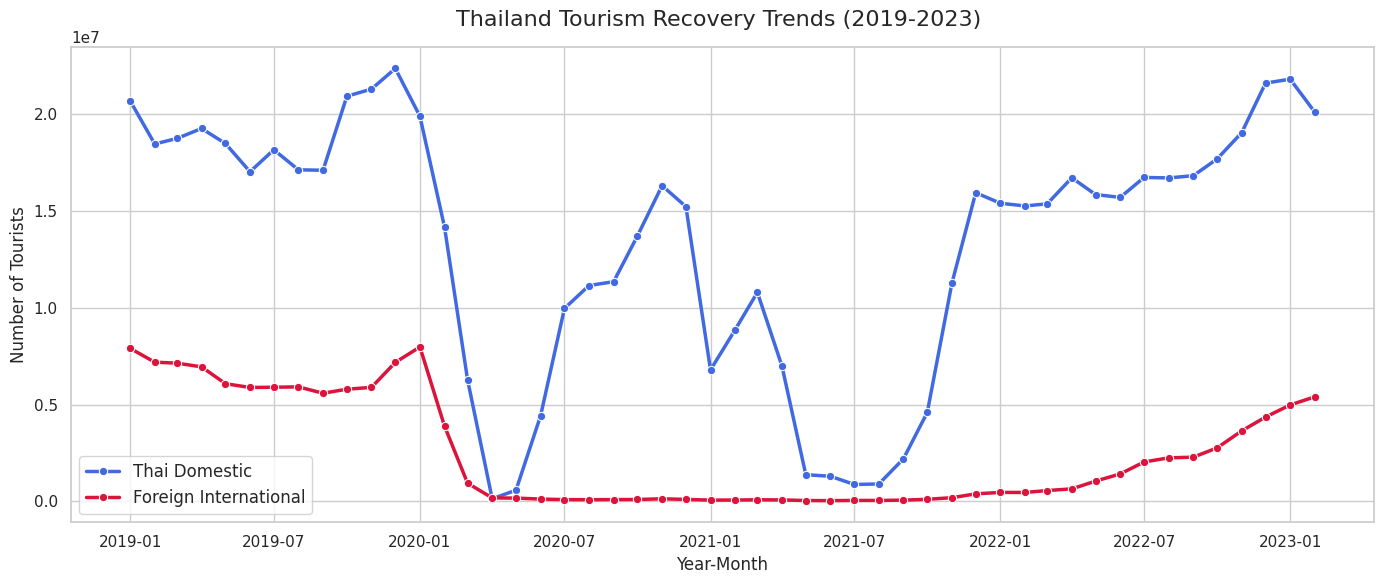

In [27]:
import glob
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# まずKaggleのフォルダの中を探します
csv_files = glob.glob("/kaggle/input/**/*.csv", recursive=True)

#  どこで動いているかに応じて、読み込むファイルの住所を自動で切り替えます
if csv_files:
    target_path = csv_files[0]
else:
    target_path = "thailand_domestic_tourism_2019_2023_ver2.csv"

#  実際にデータを読み込みます
try:
    if os.path.exists(target_path):
        df = pd.read_csv(target_path)
        print(
            f"✓ 読み込み成功: {df.shape[0]:,} 行 × {df.shape[1]} 項目（タイの観光データ）"
        )
    else:
        print("❌ CSVファイルが見つかりません。")
        df = pd.DataFrame()
except Exception as e:
    print(f"❌ エラーが発生しました: {e}")
    df = pd.DataFrame()

# 1. 必要な項目だけをフィルタリング（タイ人・外国人）
df_thai = df[df["variable"] == "no_tourist_thai"].copy()
df_foreign = df[df["variable"] == "no_tourist_foreign"].copy()

# 2. 最初から入っている 'date' 列を日付型に変換
df_thai["date_parsed"] = pd.to_datetime(df_thai["date"])
df_foreign["date_parsed"] = pd.to_datetime(df_foreign["date"])

# 3. 月ごとにタイ全土の観光客数を合計する（県ごとのデータを足し合わせる）
thai_monthly = (
    df_thai.groupby("date_parsed")["value"]
    .sum()
    .reset_index()
    .rename(columns={"value": "Thai"})
)
foreign_monthly = (
    df_foreign.groupby("date_parsed")["value"]
    .sum()
    .reset_index()
    .rename(columns={"value": "Foreign"})
)

# 4. 2つのデータを日付で合体させる
df_trends = pd.merge(thai_monthly, foreign_monthly, on="date_parsed")

# 5. いよいよ折れ線グラフの描画！
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

# タイ人と外国人の2本の線を描く
sns.lineplot(
    data=df_trends,
    x="date_parsed",
    y="Thai",
    label="Thai Domestic",
    color="royalblue",
    linewidth=2.5,
    marker="o",
)
sns.lineplot(
    data=df_trends,
    x="date_parsed",
    y="Foreign",
    label="Foreign International",
    color="crimson",
    linewidth=2.5,
    marker="o",
)

# グラフの見栄えを整える
plt.title("Thailand Tourism Recovery Trends (2019-2023) ", fontsize=16, pad=15)
plt.xlabel("Year-Month", fontsize=12)
plt.ylabel("Number of Tourists", fontsize=12)
plt.legend(fontsize=12)

# グラフを表示
plt.tight_layout()
plt.show()

In [34]:
import glob
import os
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score

# ==============================================================================
# 1. 大元のCSVデータを読み込んで、最初に「年・月」を完璧に作ります
# ==============================================================================
csv_files = glob.glob("/kaggle/input/**/*.csv", recursive=True)
if csv_files:
    target_path = csv_files[0]
else:
    target_path = "thailand_domestic_tourism_2019_2023_ver2.csv"

df= pd.read_csv(target_path)

# 日付処理
df["date_parsed"] = pd.to_datetime(df["date"])
df["year"] = df["date_parsed"].dt.year
df["month"] = df["date_parsed"].dt.month


# ==============================================================================
# 2. 🧩 【虫取り網ロジック】各データをすくい上げる（集計処理）
# ==============================================================================

# ① 【タイ人観光客数】（★薫さんの虫取り網コード）
df_thai = df[
    df["variable"].str.contains("tourist", case=False, na=False)
    & df["variable"].str.contains("domestic|thai", case=False, na=False)
].copy()

grouped_thai = (
    df_thai.groupby(["province_eng", "year", "month"])["value"]
    .sum()
    .reset_index()
)


# ② 【外国人観光客数】
df_foreign = df[df["variable"] == "no_tourist_foreign"].copy()

grouped_foreign = (
    df_foreign.groupby(["province_eng", "year", "month"])["value"]
    .sum()
    .reset_index()
)


# ③ 【合計観光収入】
df_rev = df[df["variable"].str.contains("revenue", case=False, na=False)].copy()

grouped_rev = (
    df_rev.groupby(["province_eng", "year", "month"])["value"]
    .sum()
    .reset_index()
)

# ==============================================================================
# 4. 🤝 3つのデータを「outer」で綺麗にガッチャンコ
# ==============================================================================
df_ml = grouped_thai.rename(columns={"value": "tourist_thai"})

df_ml = pd.merge(
    df_ml,
    grouped_foreign.rename(columns={"value": "tourist_foreign"}),
    on=["province_eng", "year", "month"],
    how="outer",
)

df_ml = pd.merge(
    df_ml,
    grouped_rev.rename(columns={"value": "revenue_total"}),
    on=["province_eng", "year", "month"],
    how="outer",
)

# 計算でエラーにならないよう、万が一の空っぽ（NaN）は0で埋める
df_ml = df_ml.fillna(0)

print("--- LightGBM用のベースデータ（先頭5行） ---")
display(df_ml.head())


# ==============================================================================
# 5. ⏳ 時間（年）で訓練用とテスト用に綺麗に分離する
# ==============================================================================
train_data = df_ml[df_ml["year"] <= 2022]  # 2022年までの4年間を勉強用に
test_data = df_ml[df_ml["year"] == 2023]  # 2023年の1年間を本番テスト用に


# ==============================================================================
# 6. 🧠 AIに渡す「豪華なヒント（X）」と「答え（y）」に分ける
# ==============================================================================
# 合体処理を直前で行ったので、絶対に「tourist_thaiがない」というエラーは起きません！
features = ["province_eng", "year", "month", "tourist_thai", "tourist_foreign"]

X_train = train_data[features].copy()
X_test = test_data[features].copy()

y_train = train_data["revenue_total"]
y_test = test_data["revenue_total"]

# 県名をAIが認識できるようにカテゴリー型に変換
X_train["province_eng"] = X_train["province_eng"].astype("category")
X_test["province_eng"] = X_test["province_eng"].astype("category")


# ==============================================================================
# 7. 🎒 ライトBGM師匠専用のデータセットに変換する
# ==============================================================================
train_set = lgb.Dataset(X_train, y_train, categorical_feature=["province_eng"])
test_set = lgb.Dataset(
    X_test, y_test, reference=train_set, categorical_feature=["province_eng"]
)


# ==============================================================================
# 8. 🎛️ AIの学習設定（パラメータ）を決める
# ==============================================================================
params = {
    "objective": "regression",
    "metric": "rmse",
    "learning_rate": 0.05,
    "verbose": -1,
}


# ==============================================================================
# 9. 🔥 【特訓開始】AIにお勉強させる
# ==============================================================================
print("\n🤖「一本道コードでデータを完全に復元しました！」")
print("🤖「コードをすべて通して、特訓を開始します！」")
model = lgb.train(
    params,
    train_set,
    num_boost_round=500,
    valid_sets=[train_set, test_set],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
)
print("🤖「特訓が完了しました！2023年の本当の予測結果を表示します！」\n")


# ==============================================================================
# 10. 🎯 【実力テスト】2023年の未来を予測する
# ==============================================================================
y_pred = model.predict(X_test)


# ==============================================================================
# 11. 📊 予測結果を人間の目で見やすいように表にする
# ==============================================================================
df_result = test_data[["province_eng", "year", "month"]].copy()
df_result["本物の観光収入（答え）"] = test_data["revenue_total"]
df_result["AIの予測した収入"] = y_pred

df_result["予測のズレ（誤差）"] = (
    df_result["本物の観光収入（答え）"] - df_result["AIの予測した収入"]
).abs()

display(df_result.head())

--- LightGBM用のベースデータ（先頭5行） ---


,province_eng,year,month,tourist_thai,tourist_foreign,revenue_total
0,Amnat Charoen,2019,1,20972.0,818.0,69020000.0
1,Amnat Charoen,2019,2,19597.0,780.0,64580000.0
2,Amnat Charoen,2019,3,24093.0,693.0,78140000.0
3,Amnat Charoen,2019,4,23089.0,703.0,64080000.0
4,Amnat Charoen,2019,5,21816.0,620.0,60220000.0



🤖「一本道コードでデータを完全に復元しました！」
🤖「薫さんのコードをすべて通して、特訓を開始します！」
🤖「特訓が完了しました！2023年の本当の予測結果を表示します！」



,province_eng,year,month,本物の観光収入（答え）,AIの予測した収入,予測のズレ（誤差）
48,Amnat Charoen,2023,1,5.192000e+07,3.849703e+08,3.330503e+08
49,Amnat Charoen,2023,2,4.740000e+07,3.771202e+08,3.297202e+08
98,Ang Thong,2023,1,1.654200e+08,5.293674e+08,3.639474e+08
99,Ang Thong,2023,2,1.947600e+08,5.553988e+08,3.606388e+08
148,Bangkok,2023,1,1.206163e+11,1.326316e+11,1.201526e+10
